In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/suicides_in_india_cleaned_data.csv')

In [3]:
data=data[data.loc[:,'type_code']=='Causes']

# we are filtering our data because it has 3 times duplication by type codes

In [4]:
plt.style.use('classic')

In [5]:
data.shape

(39531, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39531 entries, 0 to 91817
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   state      39531 non-null  object
 1   year       39531 non-null  int64 
 2   type_code  39531 non-null  object
 3   type       39531 non-null  object
 4   gender     39531 non-null  object
 5   age_group  39531 non-null  object
 6   total      39531 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.4+ MB


## 1.What is total number of suicides recorded in india across all years?

In [7]:
total_suicides=data['total'].sum()
print(total_suicides)

1440974


##2.What is total number of suicides by Gender wise(%)?

In [9]:
total_suicides_gender_wise=data.groupby('gender')['total'].sum()
print(f"Male(%):-{(total_suicides_gender_wise['Male']/total_suicides)*100:.2f}")
print(f"Female(%):-{(total_suicides_gender_wise['Female']/total_suicides)*100:.2f}")
total_suicides_gender_wise

Male(%):-64.07
Female(%):-35.93


,total
gender,
Female,517736
Male,923238


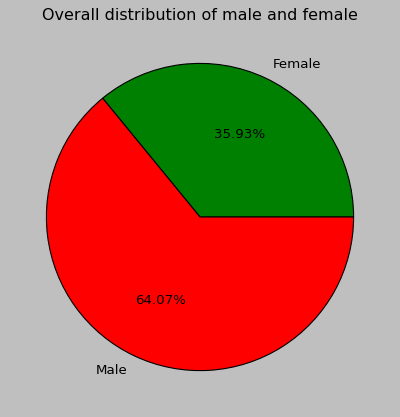

In [10]:
plt.pie(total_suicides_gender_wise.reset_index()['total'],labels=total_suicides_gender_wise.reset_index()['gender'],autopct='%0.2f%%',colors=['green','red'])
plt.title('Overall distribution of male and female')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Overall_distribution_of_male_and_female",bbox_inches='tight')
plt.show()

##3.What is total number of suicides by Year wise?

In [11]:
total_suicides_year_wise=data.groupby('year')['total'].sum().reset_index()
total_suicides_year_wise

,year,total
0,2001,108506
1,2002,110417
2,2003,110851
3,2004,113697
4,2005,113914
5,2006,118112
6,2007,122637
7,2008,125017
8,2009,127151
9,2010,134599


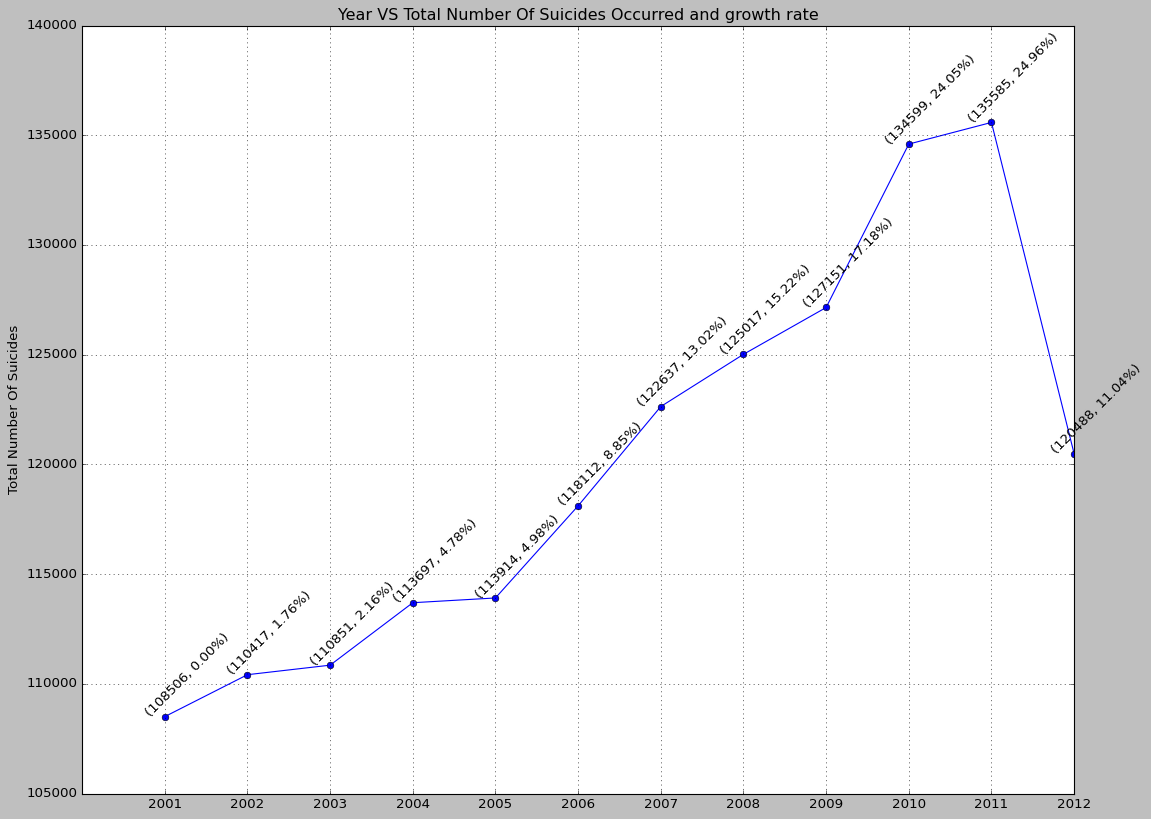

In [13]:
x=total_suicides_year_wise['year']
y=total_suicides_year_wise['total']
plt.figure(figsize=(16,12))
plt.plot(x,y,marker='o')

plt.title('Year VS Total Number Of Suicides Occurred and growth rate')
plt.ylabel('Total Number Of Suicides')
plt.xticks(x,x)

for xi,yi in zip(x,y):
  label_text=f"({yi}, {(yi-108506)/108506*100:0.2f}%)"
  plt.annotate(text=label_text,xy=(xi,yi),xytext=(20,0),textcoords='offset points',ha='center',rotation=45)

plt.grid()
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Year_VS_Total_Number_Of_Suicides_Occurred_and_growth_rate",bbox_inches='tight')
plt.show()


##4.What is the overall Age_group-wise split (%)?

In [14]:
total_suicides_age_group_wise=data.groupby('age_group')['total'].sum().reset_index()
total_suicides_age_group_wise

,age_group,total
0,0-14,32685
1,15-29,509776
2,30-44,488713
3,45-59,294333
4,60+,115467


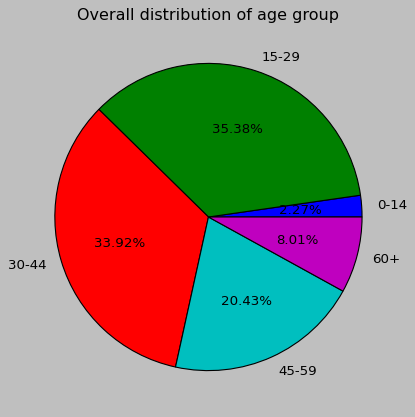

In [16]:
plt.pie(total_suicides_age_group_wise['total'],labels=total_suicides_age_group_wise['age_group'],autopct='%0.2f%%')
plt.title("Overall distribution of age group")
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Overall_distribution_of_age_group",bbox_inches="tight")
plt.show()

##5.Which states have the most and least records?

In [ ]:
least_suicide_state=data.groupby('state')['total'].sum().sort_values().head(1).reset_index()
most_suicide_state=data.groupby('state')['total'].sum().sort_values(ascending=False).head(1).reset_index()

print(f"state with least suicide records:-{least_suicide_state['state'].values[0]}, value={least_suicide_state['total'].values[0]}")
print(f"state with most suicide records:-{most_suicide_state['state'].values[0]}, value={most_suicide_state['total'].values[0]}")



state with least suicide records:-Lakshadweep, value=10
state with most suicide records:-Maharashtra, value=180389


##6.How many unique states, years categories exist? (basic shape check)

In [ ]:
print(f"Total number states:- {len(data['state'].unique())}")
print(f"Total year:- {data['year'].unique()}")


Total number states:- 35
Total year:- [2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


##7.Is the data complete for every year? (i.e., does every state report every year, or are there gaps?)

In [ ]:
data.groupby('state')['year'].nunique().sort_values()

,year
state,
Lakshadweep,6
West Bengal,11
Arunachal Pradesh,12
A & N Islands,12
Bihar,12
Chandigarh,12
Chhattisgarh,12
Andhra Pradesh,12
Daman & Diu,12


##8.Different reason for suicides

In [ ]:
pd.DataFrame(data['type'].unique())

,0
0,Love Affairs
1,Other Causes (Please Specity)
2,Other Prolonged Illness
3,Failure in Examination
4,Causes Not known
5,Family Problems
6,Insanity/Mental Illness
7,Death of Dear Person
8,Unemployment
9,Fall in Social Reputation
